#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


 ### 9. Abnormal Trading Volume Analysis

Detected trading volume column: volume
Stock price observations: 1,657,925

Analysis sample size: 8,551

News type distribution:
news_std
Good News    4527
Bad News     4024
Name: count, dtype: int64

Disclosure timing distribution:
timing_std
Intraday       4354
After-hours    3624
Pre-market      573
Name: count, dtype: int64

Missing disclosure dates: 0

Calculating abnormal trading volume...
Calculation complete.
Valid volume-ratio observations: 8,541

=== Descriptive Statistics: Abnormal Trading Volume ===
       volume_ratio  log_volume_ratio  volume_spike
count   8541.000000       8531.000000   8541.000000
mean       2.068034          0.138253      0.218944
std        6.878849          0.911613      0.413555
min        0.000000         -3.803061      0.000000
25%        0.692000         -0.365319      0.000000
50%        1.125275          0.118657      0.000000
75%        1.849508          0.615655      0.000000
max      286.799096          5.658782      1.000000

Missing rate f

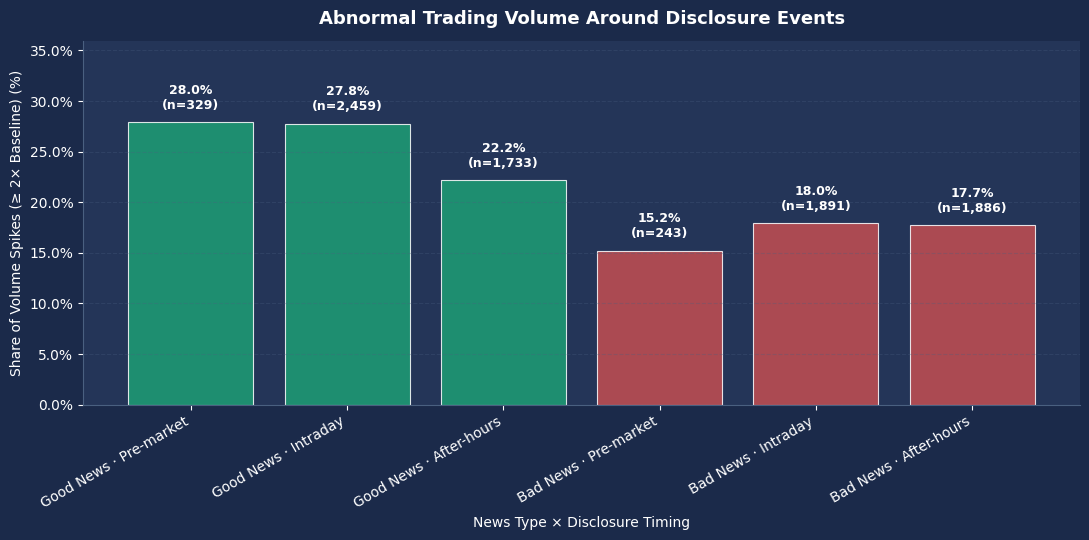

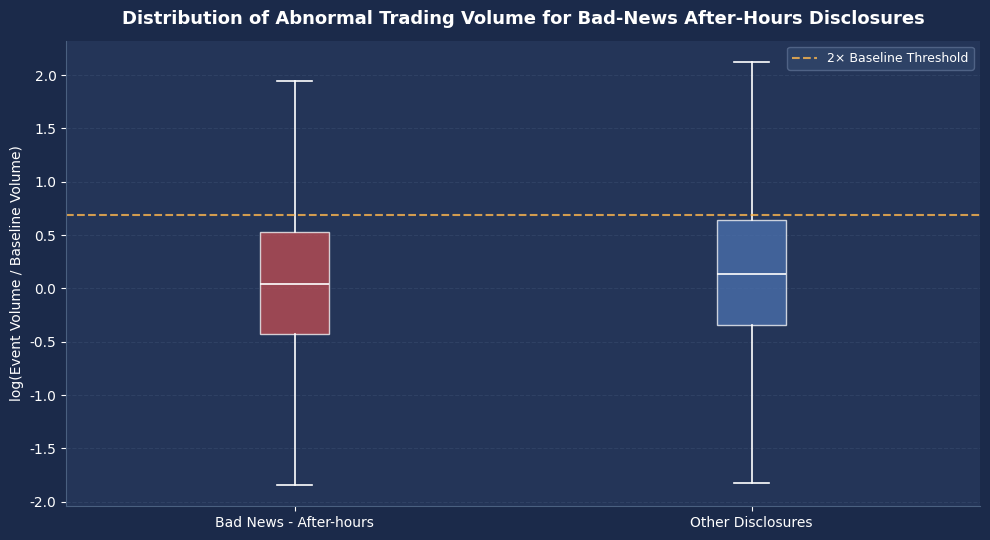


Saved output files:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\09_volume_spike_by_news_timing.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\09_volume_ratio_boxplot.png


In [5]:
# ============================================================
# 9. Abnormal Trading Volume Analysis
# - Detect abnormal increases in trading volume around disclosures
# - Benchmark: Average trading volume from 60 to 11 trading days
#   before the disclosure
# - Event window: [-1, +1] relative to the disclosure date
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import statsmodels.formula.api as smf

BG_COLOR = "#1B2A4A"

# ------------------------------------------------------------
# 1. Load stock price and trading volume data
# ------------------------------------------------------------

price_df = pd.read_csv(
    DATA_DIR / "stock_price_2018_2026.csv",
    dtype={"stock_code": str},
    low_memory=False
)

price_df["stock_code"] = (
    price_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)

price_df["date"] = pd.to_datetime(
    price_df["date"],
    errors="coerce"
)

# Automatically detect the trading volume column
volume_candidates = [
    "volume",
    "Volume",
    "거래량",
    "vol"
]

volume_col = None

for c in volume_candidates:
    if c in price_df.columns:
        volume_col = c
        break

if volume_col is None:
    print("Available columns:")
    print(price_df.columns.tolist())

    raise ValueError(
        "Trading volume column could not be found."
    )

price_df[volume_col] = pd.to_numeric(
    price_df[volume_col],
    errors="coerce"
)

price_df = (
    price_df
    .dropna(
        subset=[
            "stock_code",
            "date",
            volume_col
        ]
    )
    .copy()
)

price_df = (
    price_df
    .sort_values(
        ["stock_code", "date"]
    )
    .reset_index(drop=True)
)

print(
    f"Detected trading volume column: {volume_col}"
)

print(
    f"Stock price observations: {len(price_df):,}"
)

# ------------------------------------------------------------
# 2. Prepare event data
# ------------------------------------------------------------

vol_df = df_hb.copy()

# Standardize news-type labels so that both
# Korean and English source values can be handled
news_map = {
    "호재": "Good News",
    "악재": "Bad News",
    "Good News": "Good News",
    "Bad News": "Bad News",
    "good": "Good News",
    "bad": "Bad News",
    "GOOD": "Good News",
    "BAD": "Bad News"
}

# Standardize disclosure-timing labels
timing_map = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours",

    "Pre-market": "Pre-market",
    "Premarket": "Pre-market",
    "Pre-Market": "Pre-market",
    "Pre Market": "Pre-market",

    "Intraday": "Intraday",
    "Intra-day": "Intraday",

    "After-hours": "After-hours",
    "After Hours": "After-hours",
    "After-hours Disclosure": "After-hours",
    "After Market": "After-hours"
}

vol_df["news_std"] = (
    vol_df["news"]
    .astype(str)
    .str.strip()
    .map(news_map)
)

vol_df["timing_std"] = (
    vol_df["timing"]
    .astype(str)
    .str.strip()
    .map(timing_map)
)

# Keep only observations used in this analysis
vol_df = vol_df[
    vol_df["news_std"].isin(
        ["Good News", "Bad News"]
    )
    &
    vol_df["timing_std"].isin(
        [
            "Pre-market",
            "Intraday",
            "After-hours"
        ]
    )
].copy()

print(
    f"\nAnalysis sample size: {len(vol_df):,}"
)

if len(vol_df) == 0:

    print(
        "\nUnique values in df_hb['news']:"
    )
    print(
        df_hb["news"]
        .dropna()
        .unique()
    )

    print(
        "\nUnique values in df_hb['timing']:"
    )
    print(
        df_hb["timing"]
        .dropna()
        .unique()
    )

    raise ValueError(
        "No observations remain after "
        "standardizing news and timing labels."
    )

vol_df["stock_code"] = (
    vol_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)

# Robustly convert disclosure dates
if pd.api.types.is_datetime64_any_dtype(
    vol_df["rcept_dt"]
):

    vol_df["rcept_dt_dt"] = pd.to_datetime(
        vol_df["rcept_dt"],
        errors="coerce"
    )

else:

    vol_df["rcept_dt_dt"] = pd.to_datetime(
        vol_df["rcept_dt"]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        ),
        format="%Y%m%d",
        errors="coerce"
    )

vol_df["after_dummy"] = (
    vol_df["timing_std"]
    == "After-hours"
).astype(int)

vol_df["bad_dummy"] = (
    vol_df["news_std"]
    == "Bad News"
).astype(int)

print(
    "\nNews type distribution:"
)

print(
    vol_df["news_std"]
    .value_counts()
)

print(
    "\nDisclosure timing distribution:"
)

print(
    vol_df["timing_std"]
    .value_counts()
)

print(
    "\nMissing disclosure dates: "
    f"{vol_df['rcept_dt_dt'].isna().sum():,}"
)

# Remove observations without a valid disclosure date
vol_df = (
    vol_df
    .dropna(
        subset=["rcept_dt_dt"]
    )
    .copy()
)

# ------------------------------------------------------------
# 3. Create a stock-level price data dictionary
# ------------------------------------------------------------

price_by_stock = {
    code: g.reset_index(drop=True)
    for code, g
    in price_df.groupby("stock_code")
}


def get_event_index(
    stock_data,
    event_date,
    after_dummy
):
    """
    Identify the trading-day index corresponding
    to the disclosure event.

    For an after-hours disclosure, the next
    trading day is treated as the primary
    market-reaction date.
    """

    dates = (
        stock_data["date"]
        .values
        .astype("datetime64[ns]")
    )

    event_date = np.datetime64(
        pd.Timestamp(event_date)
    )

    # After-hours disclosures:
    # use the next trading day
    if after_dummy == 1:

        idx = np.searchsorted(
            dates,
            event_date,
            side="right"
        )

    # Pre-market / intraday disclosures:
    # use the event date or the next available
    # trading day
    else:

        idx = np.searchsorted(
            dates,
            event_date,
            side="left"
        )

    if idx >= len(stock_data):
        return None

    return idx


def calc_volume_abnormality(
    stock_code,
    event_date,
    after_dummy,
    base_start=-60,
    base_end=-11,
    event_start=-1,
    event_end=1,
    min_base_obs=20
):
    """
    Calculate abnormal trading volume around
    a disclosure event.

    Baseline volume:
        Mean trading volume from t=-60 to t=-11.

    Event volume:
        Mean trading volume from t=-1 to t=+1.

    Volume ratio:
        Event-period average volume divided by
        baseline average volume.

    Volume spike:
        Equals 1 when event-period average
        trading volume is at least twice the
        baseline average.
    """

    stock_data = price_by_stock.get(
        stock_code
    )

    if (
        stock_data is None
        or len(stock_data) == 0
    ):

        return pd.Series({
            "base_volume": np.nan,
            "event_volume": np.nan,
            "volume_ratio": np.nan,
            "log_volume_ratio": np.nan,
            "volume_spike": np.nan
        })

    event_idx = get_event_index(
        stock_data=stock_data,
        event_date=event_date,
        after_dummy=after_dummy
    )

    if event_idx is None:

        return pd.Series({
            "base_volume": np.nan,
            "event_volume": np.nan,
            "volume_ratio": np.nan,
            "log_volume_ratio": np.nan,
            "volume_spike": np.nan
        })

    base_s = event_idx + base_start
    base_e = event_idx + base_end

    ev_s = event_idx + event_start
    ev_e = event_idx + event_end

    # Ensure that the full windows are available
    if (
        base_s < 0
        or base_e < 0
        or ev_s < 0
        or ev_e >= len(stock_data)
    ):

        return pd.Series({
            "base_volume": np.nan,
            "event_volume": np.nan,
            "volume_ratio": np.nan,
            "log_volume_ratio": np.nan,
            "volume_spike": np.nan
        })

    base = (
        stock_data
        .iloc[
            base_s:base_e + 1
        ][volume_col]
        .dropna()
    )

    event = (
        stock_data
        .iloc[
            ev_s:ev_e + 1
        ][volume_col]
        .dropna()
    )

    if (
        len(base) < min_base_obs
        or len(event) == 0
    ):

        return pd.Series({
            "base_volume": np.nan,
            "event_volume": np.nan,
            "volume_ratio": np.nan,
            "log_volume_ratio": np.nan,
            "volume_spike": np.nan
        })

    base_volume = base.mean()
    event_volume = event.mean()

    if (
        pd.isna(base_volume)
        or base_volume <= 0
    ):

        volume_ratio = np.nan

    else:

        volume_ratio = (
            event_volume
            / base_volume
        )

    if (
        pd.notna(volume_ratio)
        and volume_ratio > 0
    ):

        log_volume_ratio = np.log(
            volume_ratio
        )

    else:

        log_volume_ratio = np.nan

    # A volume spike is defined as event-period
    # volume at least twice the baseline level
    if pd.notna(volume_ratio):

        volume_spike = int(
            volume_ratio >= 2
        )

    else:

        volume_spike = np.nan

    return pd.Series({
        "base_volume": base_volume,
        "event_volume": event_volume,
        "volume_ratio": volume_ratio,
        "log_volume_ratio": log_volume_ratio,
        "volume_spike": volume_spike
    })


# ------------------------------------------------------------
# 4. Calculate abnormal trading volume
# ------------------------------------------------------------

print(
    "\nCalculating abnormal trading volume..."
)

vol_features = vol_df.apply(
    lambda x: calc_volume_abnormality(
        stock_code=x["stock_code"],
        event_date=x["rcept_dt_dt"],
        after_dummy=x["after_dummy"]
    ),
    axis=1
)

# Explicitly define output columns to avoid errors
# when the input sample is unexpectedly empty
expected_feature_cols = [
    "base_volume",
    "event_volume",
    "volume_ratio",
    "log_volume_ratio",
    "volume_spike"
]

if len(vol_features) == 0:

    vol_features = pd.DataFrame(
        columns=expected_feature_cols
    )

elif isinstance(
    vol_features,
    pd.Series
):

    vol_features = pd.DataFrame(
        vol_features.tolist(),
        index=vol_df.index
    )

# Ensure all expected columns exist
for col in expected_feature_cols:

    if col not in vol_features.columns:
        vol_features[col] = np.nan

vol_features = (
    vol_features[
        expected_feature_cols
    ]
    .reset_index(drop=True)
)

vol_df = pd.concat(
    [
        vol_df.reset_index(drop=True),
        vol_features
    ],
    axis=1
)

print(
    "Calculation complete."
)

print(
    f"Valid volume-ratio observations: "
    f"{vol_df['volume_ratio'].notna().sum():,}"
)

if (
    vol_df["volume_ratio"]
    .notna()
    .sum()
    == 0
):

    raise ValueError(
        "No valid abnormal-volume observations "
        "were generated. Check whether stock codes, "
        "disclosure dates, and stock-price dates match."
    )

print(
    "\n=== Descriptive Statistics: "
    "Abnormal Trading Volume ==="
)

print(
    vol_df[
        [
            "volume_ratio",
            "log_volume_ratio",
            "volume_spike"
        ]
    ]
    .describe()
)

print(
    "\nMissing rate for volume ratio: "
    f"{vol_df['volume_ratio'].isna().mean() * 100:.1f}%"
)

print(
    "Share of observations with volume spikes "
    "(≥ 2× baseline): "
    f"{vol_df['volume_spike'].mean() * 100:.1f}%"
)

# ------------------------------------------------------------
# 5. Volume spike rates by news type and disclosure timing
# ------------------------------------------------------------

group_summary = (
    vol_df
    .dropna(
        subset=["volume_spike"]
    )
    .groupby(
        [
            "news_std",
            "timing_std"
        ],
        observed=True
    )
    .agg(
        n=(
            "volume_spike",
            "size"
        ),
        spike_pct=(
            "volume_spike",
            "mean"
        ),
        mean_volume_ratio=(
            "volume_ratio",
            "mean"
        ),
        median_volume_ratio=(
            "volume_ratio",
            "median"
        )
    )
    .reset_index()
)

group_summary[
    "spike_pct"
] *= 100

print(
    "\n=== Volume Spike Rates by "
    "News Type and Disclosure Timing ==="
)

print(
    group_summary
    .round({
        "spike_pct": 1,
        "mean_volume_ratio": 2,
        "median_volume_ratio": 2
    })
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 6. Compare bad-news after-hours disclosures
#    with other disclosures
# ------------------------------------------------------------

vol_df["bad_after"] = (
    (
        vol_df["bad_dummy"] == 1
    )
    &
    (
        vol_df["after_dummy"] == 1
    )
).astype(int)

test_df = (
    vol_df
    .dropna(
        subset=[
            "volume_spike",
            "log_volume_ratio"
        ]
    )
    .copy()
)

bad_after_vol = (
    test_df
    .loc[
        test_df["bad_after"] == 1,
        "log_volume_ratio"
    ]
)

other_vol = (
    test_df
    .loc[
        test_df["bad_after"] == 0,
        "log_volume_ratio"
    ]
)

print(
    "\n=== Bad-News After-Hours vs. "
    "Other Disclosures: "
    "Difference in Trading Volume Growth ==="
)

print(
    f"Bad News - After-hours: "
    f"n={len(bad_after_vol):,}"
)

print(
    f"Other Disclosures: "
    f"n={len(other_vol):,}"
)

if (
    len(bad_after_vol) >= 2
    and len(other_vol) >= 2
):

    t_stat, p_val = stats.ttest_ind(
        bad_after_vol,
        other_vol,
        equal_var=False,
        nan_policy="omit"
    )

    print(
        "Mean log volume ratio "
        "(Bad News - After-hours): "
        f"{bad_after_vol.mean():.3f}"
    )

    print(
        "Mean log volume ratio "
        "(Other Disclosures): "
        f"{other_vol.mean():.3f}"
    )

    print(
        "Difference: "
        f"{bad_after_vol.mean() - other_vol.mean():.3f}"
    )

    print(
        f"t-stat: {t_stat:.3f}"
    )

    print(
        f"p-value: {p_val:.4f}"
    )

else:

    print(
        "Insufficient observations "
        "for the Welch two-sample t-test."
    )

# ------------------------------------------------------------
# 7. Logistic regression:
#    Probability of an abnormal volume spike
# ------------------------------------------------------------

# Create Friday dummy robustly
if "weekday" in test_df.columns:

    if pd.api.types.is_numeric_dtype(
        test_df["weekday"]
    ):

        test_df["fri_dummy"] = (
            test_df["weekday"] == 4
        ).astype(int)

    else:

        weekday_text = (
            test_df["weekday"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        test_df["fri_dummy"] = (
            weekday_text.isin(
                [
                    "4",
                    "friday",
                    "fri",
                    "금요일"
                ]
            )
        ).astype(int)

else:

    test_df["fri_dummy"] = (
        pd.to_datetime(
            test_df["rcept_dt_dt"]
        )
        .dt.weekday
        .eq(4)
        .astype(int)
    )

reg_vol = test_df[
    [
        "volume_spike",
        "after_dummy",
        "bad_dummy",
        "bad_after",
        "fri_dummy"
    ]
].dropna().copy()

print(
    "\n=== Logistic Regression: "
    "Probability of an Abnormal Volume Spike ==="
)

if (
    len(reg_vol) == 0
    or reg_vol["volume_spike"].nunique() < 2
):

    print(
        "Logistic regression could not be estimated "
        "because the dependent variable has "
        "insufficient variation."
    )

    logit_vol = None

else:

    try:

        logit_vol = smf.logit(
            "volume_spike ~ "
            "after_dummy + "
            "bad_dummy + "
            "bad_after + "
            "fri_dummy",
            data=reg_vol
        ).fit(
            disp=False
        )

        print(
            logit_vol.summary()
        )

    except Exception as e:

        logit_vol = None

        print(
            "Logistic regression could not be estimated:"
        )

        print(
            str(e)
        )

# ------------------------------------------------------------
# 8. Visualization 1:
#    Volume spike rates by news type
#    and disclosure timing
# ------------------------------------------------------------

plot_df = group_summary.copy()

if len(plot_df) > 0:

    # Set a consistent category order
    news_order = [
        "Good News",
        "Bad News"
    ]

    timing_order = [
        "Pre-market",
        "Intraday",
        "After-hours"
    ]

    plot_df["news_order"] = (
        plot_df["news_std"]
        .map({
            v: i
            for i, v
            in enumerate(news_order)
        })
    )

    plot_df["timing_order"] = (
        plot_df["timing_std"]
        .map({
            v: i
            for i, v
            in enumerate(timing_order)
        })
    )

    plot_df = (
        plot_df
        .sort_values(
            [
                "news_order",
                "timing_order"
            ]
        )
        .reset_index(drop=True)
    )

    plot_df["group"] = (
        plot_df["news_std"]
        + " · "
        + plot_df["timing_std"]
    )

    fig, ax = plt.subplots(
        figsize=(11, 5.5)
    )

    fig.patch.set_facecolor(
        BG_COLOR
    )

    ax.set_facecolor(
        "#243558"
    )

    colors = [
        "#1D9E75"
        if news == "Good News"
        else "#C44E52"
        for news
        in plot_df["news_std"]
    ]

    bars = ax.bar(
        plot_df["group"],
        plot_df["spike_pct"],
        color=colors,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.8
    )

    for (
        bar,
        pct,
        n
    ) in zip(
        bars,
        plot_df["spike_pct"],
        plot_df["n"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            pct + 1.0,
            f"{pct:.1f}%\n(n={int(n):,})",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="white"
        )

    ymax = (
        plot_df["spike_pct"]
        .max()
    )

    ax.set_ylim(
        0,
        ymax + 8
    )

    ax.set_xlabel(
        "News Type × Disclosure Timing",
        fontsize=10
    )

    ax.set_ylabel(
        "Share of Volume Spikes "
        "(≥ 2× Baseline) (%)",
        fontsize=10
    )

    ax.set_title(
        "Abnormal Trading Volume "
        "Around Disclosure Events",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(
            xmax=100
        )
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    ax.spines[
        ["left", "bottom"]
    ].set_color(
        "#4A6080"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
        color="#4A6080"
    )

    ax.tick_params(
        axis="x",
        colors="white"
    )

    ax.tick_params(
        axis="y",
        colors="white"
    )

    ax.xaxis.label.set_color(
        "white"
    )

    ax.yaxis.label.set_color(
        "white"
    )

    ax.title.set_color(
        "white"
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "09_volume_spike_by_news_timing.png",
        dpi=150,
        bbox_inches="tight",
        facecolor=BG_COLOR
    )

    plt.show()

else:

    print(
        "\nVisualization 1 skipped: "
        "no valid group-level observations."
    )

# ------------------------------------------------------------
# 9. Visualization 2:
#    Distribution of abnormal trading volume
# ------------------------------------------------------------

if (
    len(bad_after_vol) > 0
    and len(other_vol) > 0
):

    fig, ax = plt.subplots(
        figsize=(10, 5.5)
    )

    fig.patch.set_facecolor(
        BG_COLOR
    )

    ax.set_facecolor(
        "#243558"
    )

    plot_data = [
        bad_after_vol,
        other_vol
    ]

    # Compatible with both older and newer
    # Matplotlib versions
    try:

        box = ax.boxplot(
            plot_data,
            tick_labels=[
                "Bad News - After-hours",
                "Other Disclosures"
            ],
            patch_artist=True,
            showfliers=False
        )

    except TypeError:

        box = ax.boxplot(
            plot_data,
            labels=[
                "Bad News - After-hours",
                "Other Disclosures"
            ],
            patch_artist=True,
            showfliers=False
        )

    box_colors = [
        "#C44E52",
        "#4C72B0"
    ]

    for patch, color in zip(
        box["boxes"],
        box_colors
    ):

        patch.set_facecolor(
            color
        )

        patch.set_alpha(
            0.75
        )

        patch.set_edgecolor(
            "white"
        )

    for element in [
        "whiskers",
        "caps",
        "medians"
    ]:

        for item in box[element]:

            item.set_color(
                "white"
            )

            item.set_linewidth(
                1.2
            )

    ax.axhline(
        np.log(2),
        color="#FFB74D",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="2× Baseline Threshold"
    )

    ax.set_ylabel(
        "log(Event Volume / Baseline Volume)",
        fontsize=10
    )

    ax.set_title(
        "Distribution of Abnormal Trading Volume "
        "for Bad-News After-Hours Disclosures",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    legend = ax.legend(
        loc="upper right",
        fontsize=9,
        framealpha=0.75
    )

    legend.get_frame().set_facecolor(
        "#32476B"
    )

    legend.get_frame().set_edgecolor(
        "#5D7092"
    )

    for text in legend.get_texts():
        text.set_color(
            "white"
        )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    ax.spines[
        ["left", "bottom"]
    ].set_color(
        "#4A6080"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
        color="#4A6080"
    )

    ax.tick_params(
        axis="x",
        colors="white"
    )

    ax.tick_params(
        axis="y",
        colors="white"
    )

    ax.xaxis.label.set_color(
        "white"
    )

    ax.yaxis.label.set_color(
        "white"
    )

    ax.title.set_color(
        "white"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "09_volume_ratio_boxplot.png",
        dpi=150,
        bbox_inches="tight",
        facecolor=BG_COLOR
    )

    plt.show()

else:

    print(
        "\nVisualization 2 skipped: "
        "one or both comparison groups "
        "have no valid observations."
    )

# ------------------------------------------------------------
# 10. Saved output files
# ------------------------------------------------------------

print(
    "\nSaved output files:"
)

print(
    OUTPUT_DIR
    / "09_volume_spike_by_news_timing.png"
)

print(
    OUTPUT_DIR
    / "09_volume_ratio_boxplot.png"
)

# 9. Abnormal Trading Volume Analysis

## 9.1. Objective

This section examines changes in trading volume around disclosure events to assess how after-hours disclosures are associated with market attention and trading activity.

In particular, abnormal trading volume around disclosure dates is measured to indirectly evaluate the intensity of investor reactions to disclosed information.

Abnormal trading volume is measured as the ratio of average trading volume during the event window `[-1, +1]` to average trading volume during the baseline period from 60 to 11 trading days before the disclosure. A **volume spike** is defined as an event-period trading volume at least twice the baseline average.

---

## 9.2. Descriptive Statistics

Across the full sample, approximately **21.9%** of disclosure events experienced a volume spike.

The mean volume ratio was **2.07**, while the median was approximately **1.13**, indicating that the mean was driven upward by a relatively small number of observations with exceptionally large increases in trading volume.

---

## 9.3. Trading Volume Response by News Type and Disclosure Timing

The results show that good-news disclosures are associated with substantially higher volume-spike rates than bad-news disclosures.

| Disclosure Type | Volume Spike Rate |
|---|---:|
| Bad News - Pre-market | 15.2% |
| Bad News - Intraday | 18.0% |
| Bad News - After-hours | 17.7% |
| Good News - Pre-market | 28.0% |
| Good News - Intraday | 27.8% |
| Good News - After-hours | 22.2% |

These results indicate that positive information is associated with stronger trading-volume responses than negative information.

After-hours disclosures also generally exhibit lower volume-spike rates than intraday disclosures, although the magnitude of this difference varies by news type.

---

## 9.4. Trading Volume Effects of Bad-News After-Hours Disclosures

A comparison between bad-news after-hours disclosures and all other disclosures shows that the former are associated with a lower average increase in trading volume.

```text
Mean log volume ratio (Bad News - After-hours) = 0.041
Mean log volume ratio (Other Disclosures)      = 0.166
Difference                                     = -0.125
t-stat                                         = -5.538
p-value                                        < 0.001
```

The difference is statistically significant, providing no evidence that bad-news after-hours disclosures are associated with unusually large increases in trading volume relative to other disclosures.

Instead, the results suggest that immediate trading activity surrounding bad-news after-hours disclosures is relatively limited compared with other disclosure events.

---

## 9.5. Logistic Regression Results

A logistic regression with the occurrence of a volume spike as the dependent variable shows that after-hours disclosure is significantly negatively associated with the probability of a volume spike.

```text
after_dummy = -0.297
p < 0.001
```

Bad-news disclosure is also significantly negatively associated with the probability of a volume spike.

```text
bad_dummy = -0.578
p < 0.001
```

By contrast, the interaction term between bad news and after-hours disclosure is positive and statistically significant.

```text
bad_after = +0.302
p = 0.006
```

This positive interaction indicates that the negative association between after-hours disclosure and volume-spike probability is partially attenuated for bad-news disclosures. In other words, although both bad news and after-hours timing are individually associated with lower volume-spike probabilities, their combined effect is less negative than would be implied by simply adding the two main effects.

Nevertheless, the descriptive results show that the absolute volume-spike rate for bad-news after-hours disclosures remains lower than that observed for good-news disclosures.

---

## 9.6. Overall Interpretation

Overall, the results indicate that after-hours disclosures are associated with weaker trading-volume responses than disclosures released during regular market hours.

Bad-news after-hours disclosures do not exhibit unusually large volume spikes; instead, their average trading-volume increase is significantly lower than that of other disclosure events. This pattern is consistent with the possibility that releasing information after market hours may reduce immediate market attention and trading activity.

However, the positive interaction between bad news and after-hours disclosure suggests that the reduction in volume-spike probability associated with after-hours timing is partially offset when the disclosed information is negative.

Taken together, these findings suggest that disclosure timing is systematically associated with the intensity of trading activity around corporate announcements. However, the results should be interpreted as evidence of **association rather than causal evidence** that firms deliberately use after-hours disclosure to suppress market attention.